# Labwork 3 -- RGB to grayscale
Le Nghiem Thanh Thuy - 2540023

In [22]:
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
from skimage import data

print("CUDA available:", cuda.is_available())

CUDA available: True


In [23]:
img = data.astronaut()
height, width, channels = img.shape
pixelCount = height * width
print("Image shape:", img.shape, "-> pixels:", pixelCount)

# flatten to a 1D list of pixels
flatSrc = img.reshape(pixelCount, channels)

Image shape: (512, 512, 3) -> pixels: 262144


## 1. CPU version


In [33]:
def grayscale_cpu(src):
    dst = np.empty_like(src)
    for i in range(src.shape[0]):
        g = (int(src[i, 0]) + int(src[i, 1]) + int(src[i, 2])) // 3
        dst[i, 0] = dst[i, 1] = dst[i, 2] = g
    return dst


start = time.time()
cpuDst = grayscale_cpu(flatSrc)
cpuTime = time.time() - start
print(f"CPU time: {cpuTime * 1000:.2f} ms")

CPU time: 257.92 ms


## 2. GPU version


In [25]:
@cuda.jit
def grayscale(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    g = np.uint8((src[tidx, 0] + src[tidx,1] + src[tidx,2]) / 3)
    dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g

In [26]:
blockSize = 64
gridSize = pixelCount // blockSize
print("blockSize:", blockSize, "gridSize:", gridSize)


blockSize: 64 gridSize: 4096


In [27]:
start = time.time()
devSrc = cuda.to_device(flatSrc)
devDst = cuda.device_array((pixelCount, channels), np.uint8)
grayscale[gridSize, blockSize](devSrc, devDst)
gpuDst = devDst.copy_to_host()
gpuTime = time.time() - start

print(f"GPU time 1 : {gpuTime * 1000:.2f} ms")

GPU time 1 : 148.44 ms


In [28]:
# whole GPU work, including copying the image to and from the device
start = time.time()
devSrc = cuda.to_device(flatSrc)
devDst = cuda.device_array((pixelCount, channels), np.uint8)
grayscale[gridSize, blockSize](devSrc, devDst)
gpuDst = devDst.copy_to_host()
gpuTime = time.time() - start

print(f"GPU time 2 : {gpuTime * 1000:.2f} ms")


GPU time 2 : 3.92 ms


## 3. Comparison

In [34]:
print("Same result as CPU:", np.array_equal(cpuDst, gpuDst))
print(f"CPU : {cpuTime * 1000:.2f} ms")
print(f"GPU : {gpuTime * 1000:.2f} ms  -> speedup {cpuTime / gpuTime:.1f}x")

Same result as CPU: True
CPU : 257.92 ms
GPU : 3.92 ms  -> speedup 65.8x


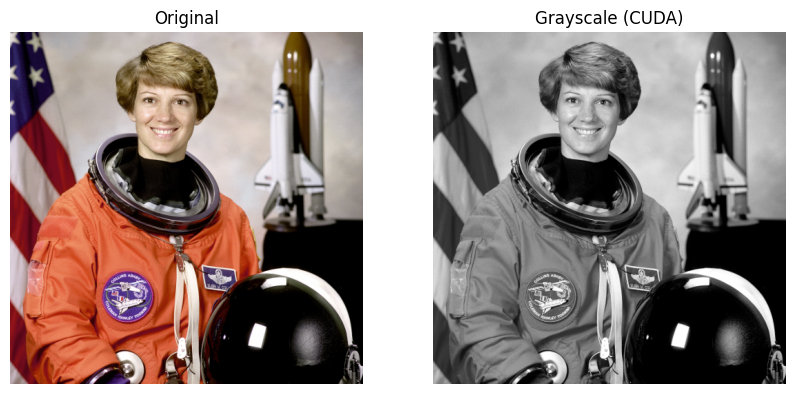

In [30]:
gray_img = gpuDst.reshape(height, width, channels)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Grayscale (CUDA)")
plt.imshow(gray_img)
plt.axis("off")
plt.show()

## 4. Different block sizes

In [31]:
lsBlockSizes = [16, 32, 64, 128, 256, 512, 1024]
nRuns = 100

# copy the image once, outside the loop
devSrc = cuda.to_device(flatSrc)
devDst = cuda.device_array((pixelCount, channels), np.uint8)

lsGPUTimes = []
for blockSize in lsBlockSizes:
    gridSize = pixelCount // blockSize

    # warm-up, not measured
    grayscale[gridSize, blockSize](devSrc, devDst)
    cuda.synchronize()

    start = time.time()
    for _ in range(nRuns):
        grayscale[gridSize, blockSize](devSrc, devDst)
    cuda.synchronize()
    kernelTime = (time.time() - start) / nRuns

    lsGPUTimes.append(kernelTime)
    print(f"blockSize {blockSize:4d}  gridSize {gridSize:6d}  ->  {kernelTime * 1000:.4f} ms")

bestBlockSize = lsBlockSizes[int(np.argmin(lsGPUTimes))]
print("\nFastest block size:", bestBlockSize)

blockSize   16  gridSize  16384  ->  0.1523 ms
blockSize   32  gridSize   8192  ->  0.1042 ms
blockSize   64  gridSize   4096  ->  0.0845 ms
blockSize  128  gridSize   2048  ->  0.0997 ms
blockSize  256  gridSize   1024  ->  0.0860 ms
blockSize  512  gridSize    512  ->  0.0978 ms
blockSize 1024  gridSize    256  ->  0.0921 ms

Fastest block size: 64


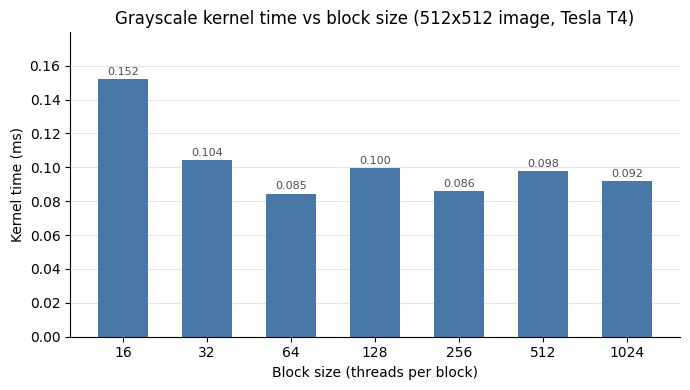

In [32]:
timesMs = [t * 1000 for t in lsGPUTimes]
labels = [str(b) for b in lsBlockSizes]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, timesMs, width=0.6, color="#4878a8")

ax.set_title("Grayscale kernel time vs block size (512x512 image, Tesla T4)")
ax.set_xlabel("Block size (threads per block)")
ax.set_ylabel("Kernel time (ms)")

ax.set_ylim(0, max(timesMs) * 1.18)
ax.grid(axis="y", color="0.9")
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, t in zip(bars, timesMs):
    ax.annotate(f"{t:.3f}",
                (bar.get_x() + bar.get_width() / 2, t),
                textcoords="offset points", xytext=(0, 3),
                ha="center", fontsize=8, color="0.3")

plt.tight_layout()
plt.savefig("blocksize.png", dpi=150)
plt.show()